<a href="https://colab.research.google.com/github/RogMaverick18/Speech-Processing-Lab-assignments/blob/main/task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Processing: LJ004-0143.wav


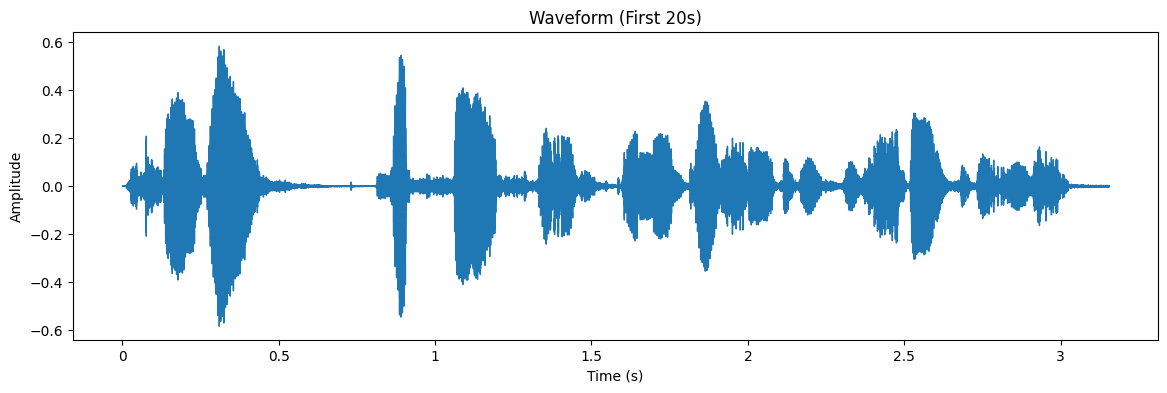

Frame Length: 400 samples (25ms)
Frame Shift: 160 samples (10ms)
Total Frames: 313


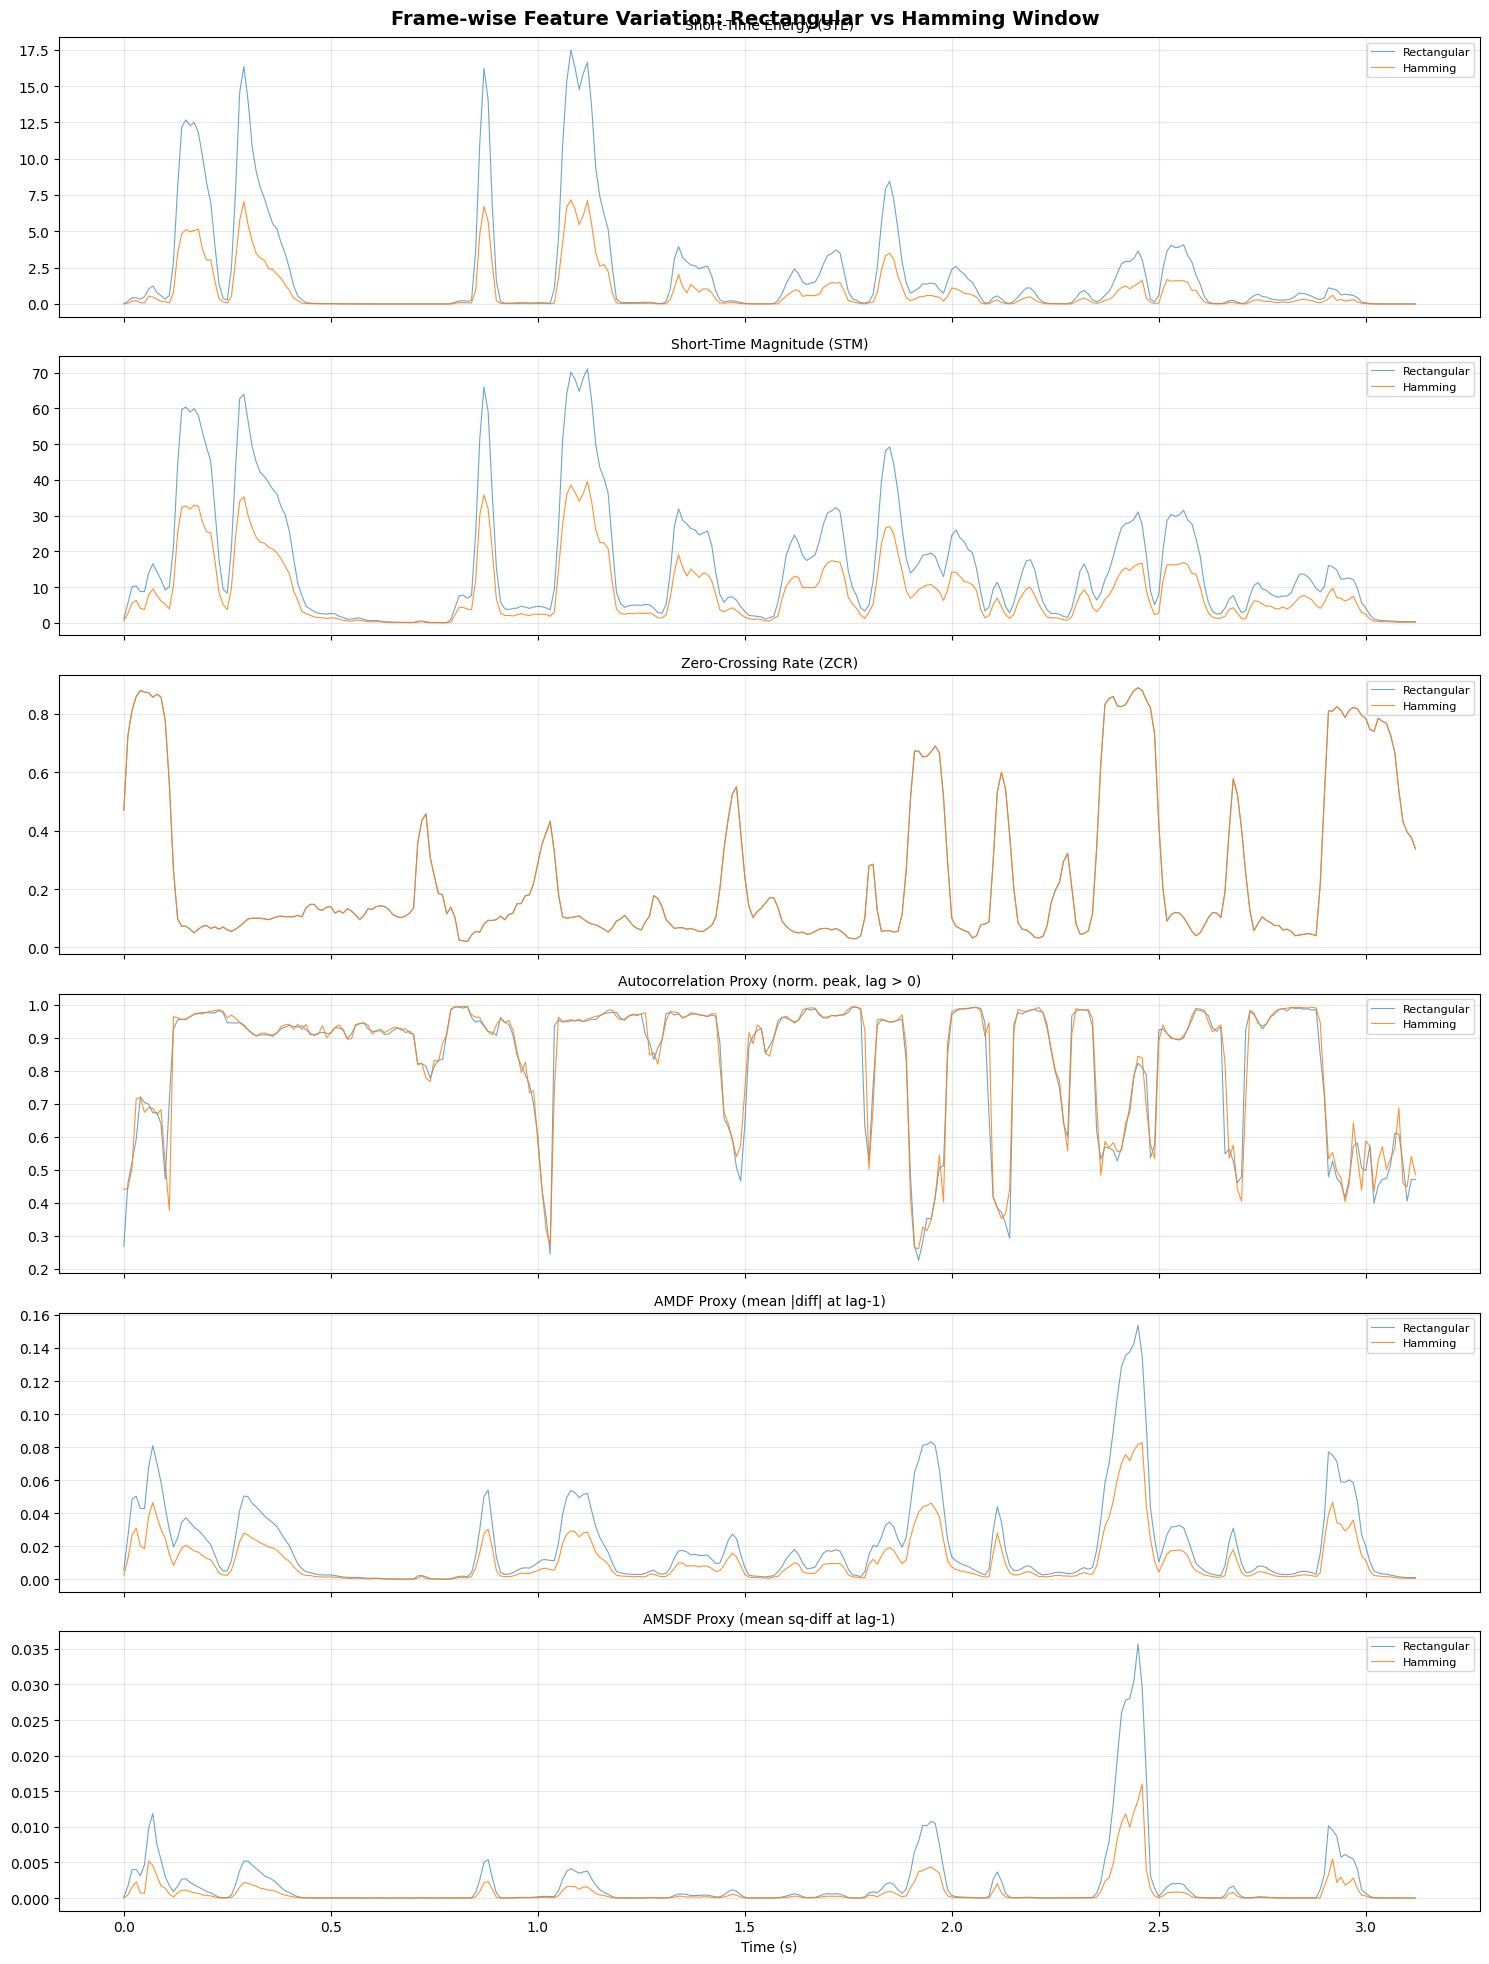

In [ ]:
# ==========================================
# TASK 1: SHORT-TIME PROCESSING & FEATURE EXTRACTION
# ==========================================

# 1. INSTALLATION & IMPORTS
# ------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import os
import urllib.request

# 2. CONFIGURATION
# ------------------------------------------
# Path to LJ Speech dataset in Kaggle (adjust if needed)
DATASET_DIR = "/kaggle/input/datasets/mathurinache/the-lj-speech-dataset/LJSpeech-1.1/wavs/"
# Pick the first file automatically
FILE_PATH = os.path.join(DATASET_DIR, os.listdir(DATASET_DIR)[0])

SAMPLE_RATE = 16000
FRAME_LENGTH_MS = 25
FRAME_SHIFT_MS = 10
DURATION = 20  # Seconds to analyze

# 3. HELPER FUNCTIONS
# ------------------------------------------
def compute_features(frames, sample_rate):
    """Computes time-domain features for a matrix of frames."""
    n_frames, frame_len = frames.shape

    ste = np.sum(frames**2, axis=1)
    stm = np.sum(np.abs(frames), axis=1)

    # Zero Crossing Rate (simple sign change count)
    zcr = np.sum(np.abs(np.diff(np.sign(frames), axis=1)), axis=1) / (2 * frame_len)

    return ste, stm, zcr

def get_periodicity_proxies(frame_matrix):
    """
    Frame-wise scalar proxies for Autocorrelation, AMDF, AMSDF.
    Used to plot frame-wise variation across the entire signal.
    """
    max_ac    = []
    min_amdf  = []
    min_amsdf = []

    for frame in frame_matrix:
        # Autocorr – normalised peak at lag > 0
        ac = np.correlate(frame, frame, mode='full')
        ac = ac[len(ac)//2:]             # non-negative lags
        r0 = ac[0] if ac[0] != 0 else 1e-10
        max_ac.append(np.max(ac[1:]) / r0 if len(ac) > 1 else 0)

        # AMDF proxy – mean |x(n) – x(n+1)| at lag 1
        diff = np.abs(frame[:-1] - frame[1:])
        min_amdf.append(np.mean(diff))

        # AMSDF proxy – mean (x(n) – x(n+1))^2 at lag 1
        min_amsdf.append(np.mean(diff**2))

    return np.array(max_ac), np.array(min_amdf), np.array(min_amsdf)

# 4. MAIN PROCESSING
# ------------------------------------------
if os.path.exists(FILE_PATH):
    print(f"Processing: {os.path.basename(FILE_PATH)}")

    # a) Load and visualize first 20s
    y, sr = librosa.load(FILE_PATH, sr=SAMPLE_RATE, duration=DURATION)

    plt.figure(figsize=(14, 4))
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Waveform (First {DURATION}s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.show()

    # b) Compute total frames
    frame_len_samples = int(SAMPLE_RATE * FRAME_LENGTH_MS / 1000)
    frame_shift_samples = int(SAMPLE_RATE * FRAME_SHIFT_MS / 1000)

    total_samples = len(y)
    num_frames = int((total_samples - frame_len_samples) / frame_shift_samples) + 1
    print(f"Frame Length: {frame_len_samples} samples ({FRAME_LENGTH_MS}ms)")
    print(f"Frame Shift: {frame_shift_samples} samples ({FRAME_SHIFT_MS}ms)")
    print(f"Total Frames: {num_frames}")

    # c) Segment into overlapping frames
    # librosa.util.frame → shape (frame_length, n_frames); transpose to (n_frames, frame_length)
    frames = librosa.util.frame(y, frame_length=frame_len_samples, hop_length=frame_shift_samples).T
    num_frames = frames.shape[0]   # FIX: use actual count from librosa, not formula

    # d) & e) Apply Windows (Hamming vs Rectangular)
    # Rectangular (No modification, just the raw frames)
    rect_frames = frames.copy()

    # Hamming
    hamming_window = np.hamming(frame_len_samples)
    hamming_frames = frames * hamming_window

    # Extract Features (Scalar)
    # 1. STE, 2. STM, 3. ZCR
    ste_rect, stm_rect, zcr_rect = compute_features(rect_frames, sr)
    ste_ham, stm_ham, zcr_ham = compute_features(hamming_frames, sr)

    # 4. Autocorr  5. AMDF  6. AMSDF  (scalar proxies for frame-wise plot)
    # Uses the get_periodicity_proxies defined above (normalised, correct version)
    ac_rect, amdf_rect, amsdf_rect = get_periodicity_proxies(rect_frames)
    ac_ham, amdf_ham, amsdf_ham = get_periodicity_proxies(hamming_frames)

    # f) Plot frame-wise variation of all 6 features for both windows
    time_axis = np.arange(num_frames) * (frame_shift_samples / SAMPLE_RATE)

    feature_data = [
        ("Short-Time Energy (STE)",                       ste_rect,   ste_ham),
        ("Short-Time Magnitude (STM)",                     stm_rect,   stm_ham),
        ("Zero-Crossing Rate (ZCR)",                       zcr_rect,   zcr_ham),
        ("Autocorrelation Proxy (norm. peak, lag > 0)",    ac_rect,    ac_ham),
        ("AMDF Proxy (mean |diff| at lag-1)",              amdf_rect,  amdf_ham),
        ("AMSDF Proxy (mean sq-diff at lag-1)",            amsdf_rect, amsdf_ham),
    ]

    fig, axes = plt.subplots(6, 1, figsize=(15, 20), sharex=True)
    fig.suptitle("Frame-wise Feature Variation: Rectangular vs Hamming Window",
                 fontsize=14, fontweight='bold')

    for ax, (title, f_rect, f_ham) in zip(axes, feature_data):
        ax.plot(time_axis, f_rect, label="Rectangular", alpha=0.65, linewidth=0.8)
        ax.plot(time_axis, f_ham,  label="Hamming",     alpha=0.85, linewidth=0.8)
        ax.set_title(title, fontsize=10)
        ax.legend(loc="upper right", fontsize=8)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

else:
    print("File not found! Check DATASET_DIR.")

## (g) Analysis: Voiced vs Unvoiced Behaviour of All Six Features

| Feature | Voiced Segments | Unvoiced Segments |
|---|---|---|
| **Short-Time Energy (STE)** | **High** — vocal-fold vibration produces strong, periodic amplitude bursts (e.g., vowels). | **Low** — turbulent airflow through constrictions produces weak, random energy (e.g., /s/, /f/). |
| **Short-Time Magnitude (STM)** | **High** — directly proportional to STE; mirrors the amplitude envelope of voiced regions. | **Low** — aperiodic, low-amplitude signal gives a small sum of absolute values. |
| **Zero-Crossing Rate (ZCR)** | **Low** (≈ 10–50 crossings/frame) — near-sinusoidal periodic waveform crosses zero at a predictable, low rate. | **High** (≈ 50–150 crossings/frame) — noise-like signal crosses zero randomly and very frequently. ZCR is one of the best simple V/UV discriminators. |
| **Autocorrelation proxy** | **High** — the normalised peak at the pitch-period lag is large, reflecting strong periodicity. | **Low / flat** — no consistent periodic structure; no prominent peak beyond lag-0. |
| **AMDF proxy** | **Low** — adjacent samples are similar in a smooth, periodic waveform, so mean magnitude difference is small. | **High** — large random sample-to-sample variation due to turbulence raises the mean difference. |
| **AMSDF proxy** | **Low** — squared differences amplify the contrast; periodic signals show deep, well-defined minima. | **High** — no recurring minimum; values fluctuate without any periodic pattern. |

**Summary of inferences:**
- STE, STM, and the autocorrelation proxy **peak during voiced** (periodic) speech and are low during unvoiced/silence.
- ZCR behaves **inversely** — low for voiced, high for unvoiced — making it a reliable complement to STE for V/UV decision.
- AMDF and AMSDF are **low for voiced** and high for unvoiced; their minima locate the pitch period in Task 2 & 3.

## (h) Effect of Window Choice on Feature Smoothness and Discrimination

| Criterion | Rectangular Window | Hamming Window |
|---|---|---|
| **Spectral leakage** | High — abrupt discontinuities at frame edges create strong side-lobes. | Low — smooth taper to zero at both edges minimises spectral leakage. |
| **Feature smoothness** | Features fluctuate more due to edge discontinuities and transient artefacts. | Features are visibly smoother, better reflecting gradual amplitude changes. |
| **Absolute amplitude** | Preserves full energy (unity gain at every sample). | Slightly reduces energy (Hamming gain ≈ 0.54 at edges), so STE/STM values are numerically lower. |
| **V/UV discrimination** | Acceptable, but occasional spurious peaks near frame boundaries reduce reliability. | Better — transient artefacts are suppressed, making STE and ZCR decision boundaries cleaner. |
| **Pitch-related features (AC/AMDF/AMSDF)** | Edge discontinuities can introduce false peaks or fill in the AMDF/AMSDF minima. | Yields cleaner lag-domain profiles: the pitch peak / AMDF minimum stands out more clearly. |

**Conclusion:** The **Hamming window** is preferred for voiced/unvoiced segmentation and pitch analysis because it reduces spectral leakage and edge artefacts, producing smoother and more discriminative feature trajectories. The **Rectangular window** is simpler, has 100 % time-overlap fidelity, and is acceptable when only relative amplitude trends matter.
